In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
df = pd.read_csv("/content/loan_approv_dataset.csv")

In [62]:
df.head()

,age,salary,years_experience,credit_score,loan_amount,loan_approved
0,22,22000,0,610,150000,0
1,35,48000,8,720,300000,1
2,28,32000,3,650,220000,0
3,42,75000,15,790,450000,1
4,31,52000,6,700,280000,1


In [63]:
df.tail()

,age,salary,years_experience,credit_score,loan_amount,loan_approved
25,37,65000,10,760,370000,1
26,23,24000,1,605,155000,0
27,43,85000,17,795,460000,1
28,31,47000,5,695,260000,1
29,29,39000,4,670,225000,0


In [64]:
df.columns

Index(['age', 'salary', 'years_experience', 'credit_score', 'loan_amount',
       'loan_approved'],
      dtype='object')

In [65]:
df.dtypes

,0
age,int64
salary,int64
years_experience,int64
credit_score,int64
loan_amount,int64
loan_approved,int64


In [66]:
df.shape

(30, 6)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               30 non-null     int64
 1   salary            30 non-null     int64
 2   years_experience  30 non-null     int64
 3   credit_score      30 non-null     int64
 4   loan_amount       30 non-null     int64
 5   loan_approved     30 non-null     int64
dtypes: int64(6)
memory usage: 1.5 KB


In [68]:
df.describe()

,age,salary,years_experience,credit_score,loan_amount,loan_approved
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,32.766667,51666.666667,7.366667,704.833333,297166.666667,0.633333
std,7.518636,22077.189560,5.979755,69.932028,118617.636455,0.490133
min,21.000000,21000.000000,0.000000,590.000000,130000.000000,0.000000
25%,27.250000,32250.000000,2.250000,646.250000,212500.000000,0.000000
50%,31.500000,49000.000000,6.000000,702.500000,277500.000000,1.000000
75%,38.750000,69500.000000,11.750000,767.500000,385000.000000,1.000000
max,47.000000,95000.000000,20.000000,820.000000,550000.000000,1.000000


In [69]:
df.isnull().sum()

,0
age,0
salary,0
years_experience,0
credit_score,0
loan_amount,0
loan_approved,0


In [70]:
df.duplicated().sum()

np.int64(0)

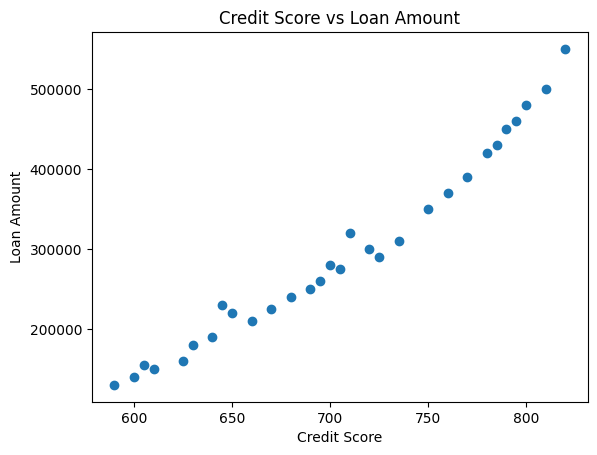

In [71]:
plt.scatter(df['credit_score'],df['loan_amount'])
plt.title("Credit Score vs Loan Amount")
plt.xlabel("Credit Score")
plt.ylabel("Loan Amount")
plt.show()

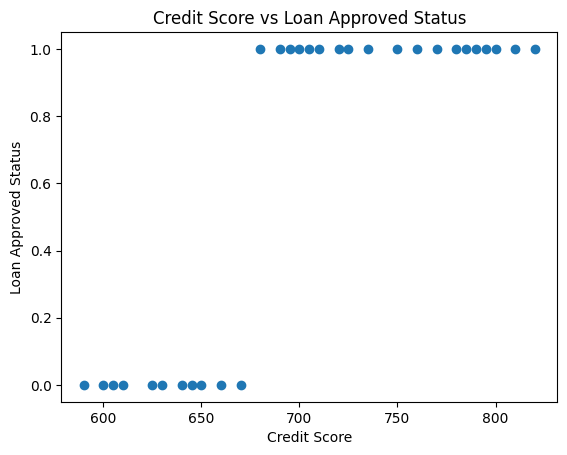

In [72]:
plt.scatter(df['credit_score'],df['loan_approved'])
plt.title("Credit Score vs Loan Approved Status")
plt.xlabel("Credit Score")
plt.ylabel("Loan Approved Status")
plt.show()

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [74]:
X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [76]:
model = RandomForestClassifier(n_estimators=100,random_state=42)


In [77]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [78]:
y_pred = model.predict(X_test)
print(y_pred)

[1 1 1 1 1 0]


In [79]:
model.score(X_test,y_test)

1.0

In [80]:
model.score(X_train,y_train)

1.0

In [81]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [82]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 1.0


In [83]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 1.0


In [84]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 1.0


In [85]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         5

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



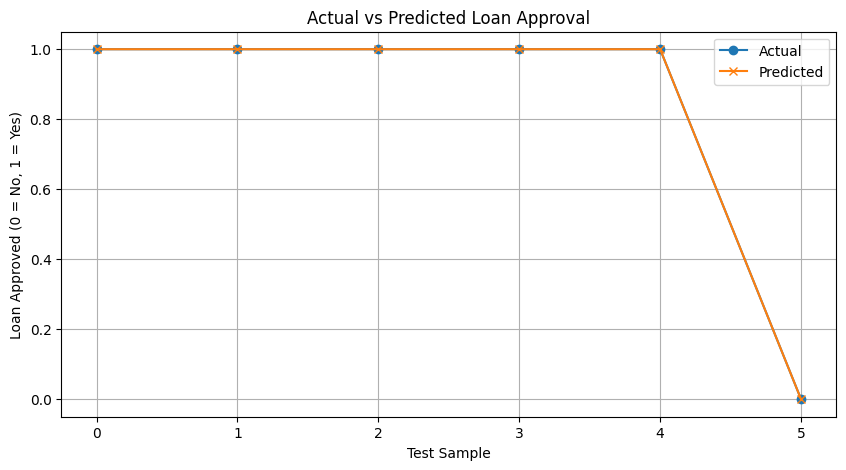

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(range(len(y_test)), y_test.values, marker='o', label='Actual')
plt.plot(range(len(y_pred)), y_pred, marker='x', label='Predicted')

plt.xlabel("Test Sample")
plt.ylabel("Loan Approved (0 = No, 1 = Yes)")
plt.title("Actual vs Predicted Loan Approval")

plt.legend()
plt.grid(True)
plt.show()

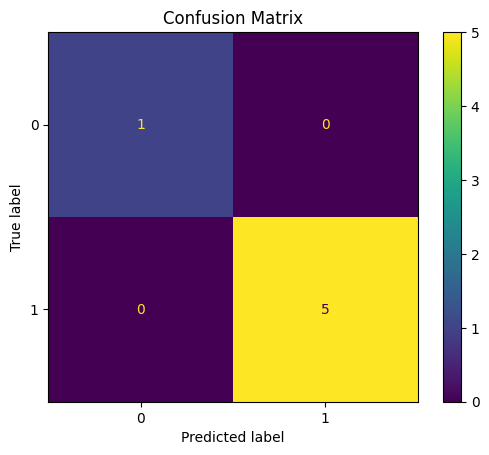

In [87]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()